In [22]:
import torch 
import torch.nn as nn 

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"


In [4]:
from torch.utils.data import DataLoader
from eb_jepa.datasets.moving_mnist import MovingMNISTDet


train_set = MovingMNISTDet(split="train")
val_set   = MovingMNISTDet(split="val")

train_loader = DataLoader(train_set, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False, num_workers=2)

In [24]:
batch = next(iter(train_loader))
print(batch["video"].shape)

torch.Size([64, 1, 10, 64, 64])


In [ ]:
from architectures import (
    ResNet5,
    ResUNet, 
    StateOnlyPredictor,
    Projector,
    DetHead
    )

from jepa import JEPA, JEPAProbe
from image_decoder import ImageDecoder
from losses import VCLoss, SquareLossSeq
from eb_jepa.training_utils import load_config



fname = "cfgs/default.yaml"
cfg = load_config(fname)

encoder = ResNet5(cfg.model.dobs, cfg.model.henc, cfg.model.dstc)
predictor_model = ResUNet(2 * cfg.model.dstc, cfg.model.hpre, cfg.model.dstc, is_rnn= False)    # is_rnn = False is default (being explicit).
predictor = StateOnlyPredictor(predictor_model,context_length=2)
projector = Projector(f"{cfg.model.dstc}-{cfg.model.dstc*4}-{cfg.model.dstc*4}")
regularizer = VCLoss(cfg.loss.std_coeff, cfg.loss.cov_coeff, proj=projector)
ploss = SquareLossSeq(projector)
jepa = JEPA(encoder, encoder, predictor, regularizer, ploss).to(device)

# Initialize decoder and detection head (for evaluation only)
decoder = ImageDecoder(cfg.model.dstc, cfg.model.dobs)
dethead = DetHead(cfg.model.dstc, cfg.model.hpre, cfg.model.dobs)
pixel_decoder = JEPAProbe(jepa, decoder, nn.MSELoss()).to(device)
detection_head = JEPAProbe(jepa, dethead, nn.BCELoss()).to(device)

In [ ]:
jepa_ckpt_20        = torch.load("artifacts/epoch_20.pth.tar", map_location= device)
decoder_ckpt_latest = torch.load("artifacts/decoder_latest.pth.tar", map_location= device)
dethead_ckpt_latest = torch.load("artifacts/detection_latest.pth.tar", map_location= device)


# jepa.load_state_dict(jepa_ckpt_20["model_state_dict"])    # it will be overwrite it 
# this silently overwrites above jepa weights, but that's okay they are identical since the following was trainined on jepa @ epoch 20 
pixel_decoder.load_state_dict(decoder_ckpt_latest["model_state_dict"])  
detection_head.load_state_dict(dethead_ckpt_latest["model_state_dict"]) 

# just ot be on the safe side, 
jepa.load_state_dict(jepa_ckpt_20["model_state_dict"])

<All keys matched successfully>

In [15]:
jepa.eval()
pixel_decoder.eval()
detection_head.eval()

JEPAProbe(
  (jepa): JEPA(
    (encoder): ResNet5(
      (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (layer1): ResidualBlock(
        (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (shortcut): Sequential()
      )
      (layer2): ResidualBlock(
        (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(in

In [25]:
encoder.eval()
with torch.no_grad(): 
    state = encoder(batch["video"].to(device))
    print(state.shape)

torch.Size([64, 16, 10, 64, 64])


In [26]:
state

tensor([[[[[ 0.0000,  0.0000,  0.0000,  ...,  0.3834,  6.5686,  0.0000],
           [ 0.5011,  1.1328,  0.9761,  ...,  0.0000, 12.3940,  0.0000],
           [ 0.2898,  1.9407,  1.5511,  ...,  8.5109, 17.0609,  0.0000],
           ...,
           [ 4.3932,  0.0000,  9.2292,  ...,  3.9215, 17.7926,  0.0000],
           [ 6.4752,  0.0000,  1.5802,  ...,  0.0000, 13.8720,  0.0000],
           [ 7.3429,  1.6819,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],

          [[ 0.0000,  0.0000,  0.0000,  ...,  0.3834,  6.5686,  0.0000],
           [ 0.5011,  1.1328,  0.9761,  ...,  0.0000, 12.3940,  0.0000],
           [ 0.2898,  1.9407,  1.5511,  ...,  8.5109, 17.0609,  0.0000],
           ...,
           [ 4.3932,  0.0000,  9.2292,  ...,  3.9215, 17.7926,  0.0000],
           [ 6.4752,  0.0000,  1.5802,  ...,  0.0000, 13.8720,  0.0000],
           [ 7.3429,  1.6819,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],

          [[ 0.0000,  0.0000,  0.0000,  ...,  0.3834,  6.5686,  0.0000],
           [ 0.

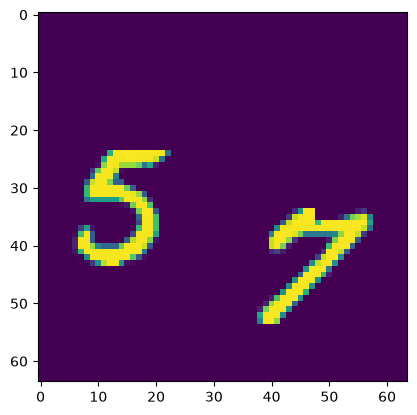

In [ ]:
import matplotlib.pyplot as plt 

plt.imshow(batch["video"][0,0,0])

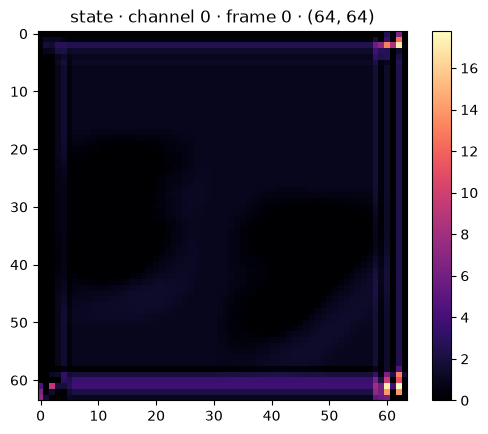

In [ ]:

encoder.eval()
with torch.no_grad():
    state = encoder(batch["video"].to(device))   # (B, dstc, T, H', W')

fmap = state[0, 0, 0].cpu()                      # video 0, feature channel 0, frame 0

plt.imshow(fmap, cmap="magma")
plt.title(f"state · channel 0 · frame 0 · {tuple(fmap.shape)}")
plt.colorbar()
plt.show()


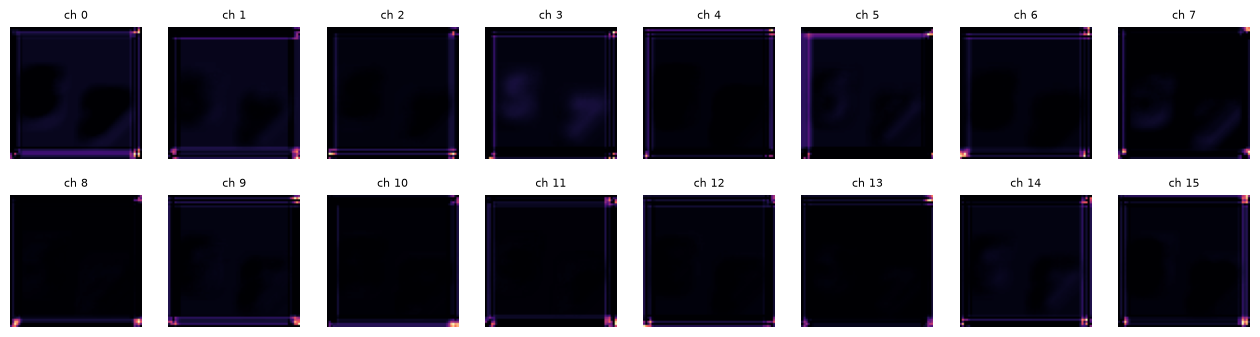

In [32]:
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for k, ax in enumerate(axes.flat):
    ax.imshow(state[0, k, 0].cpu(), cmap="magma")
    ax.set_title(f"ch {k}", fontsize=8)
    ax.axis("off")
plt.show()
